In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
cols=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
(df[cols]==0).sum()

Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

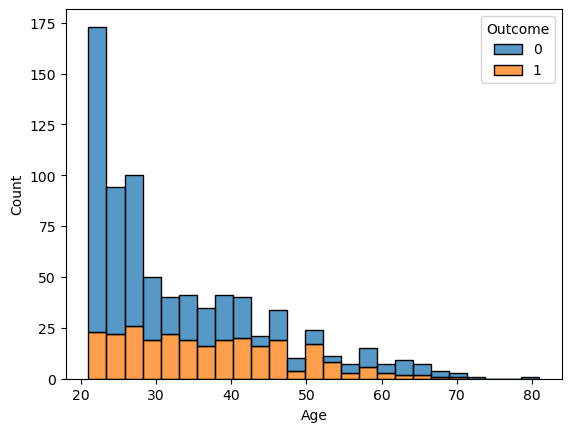

In [8]:
sns.histplot(data=df, x='Age', hue='Outcome', multiple='stack', bins=25)

<Axes: xlabel='Age', ylabel='Outcome'>

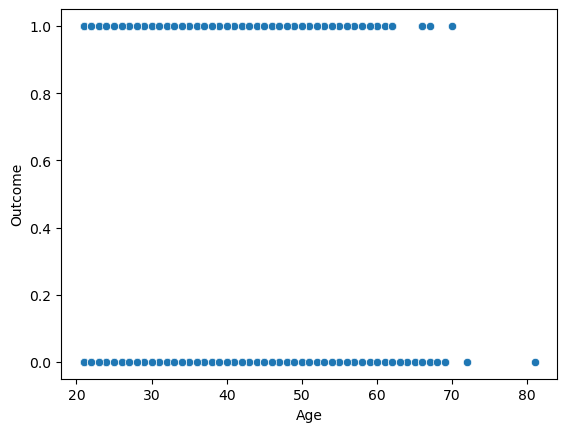

In [9]:
sns.scatterplot(data=df, x='Age', y='Outcome')

<Axes: xlabel='BMI', ylabel='Count'>

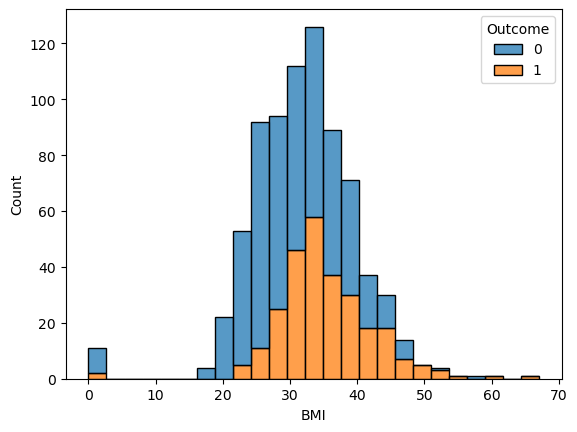

In [10]:
sns.histplot(data=df, x='BMI', hue='Outcome', multiple='stack', bins=25)

In [11]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


<Axes: xlabel='Outcome', ylabel='count'>

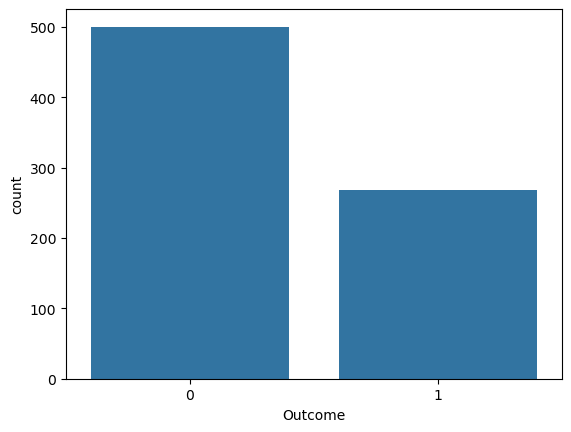

In [12]:
sns.countplot(data=df, x='Outcome')

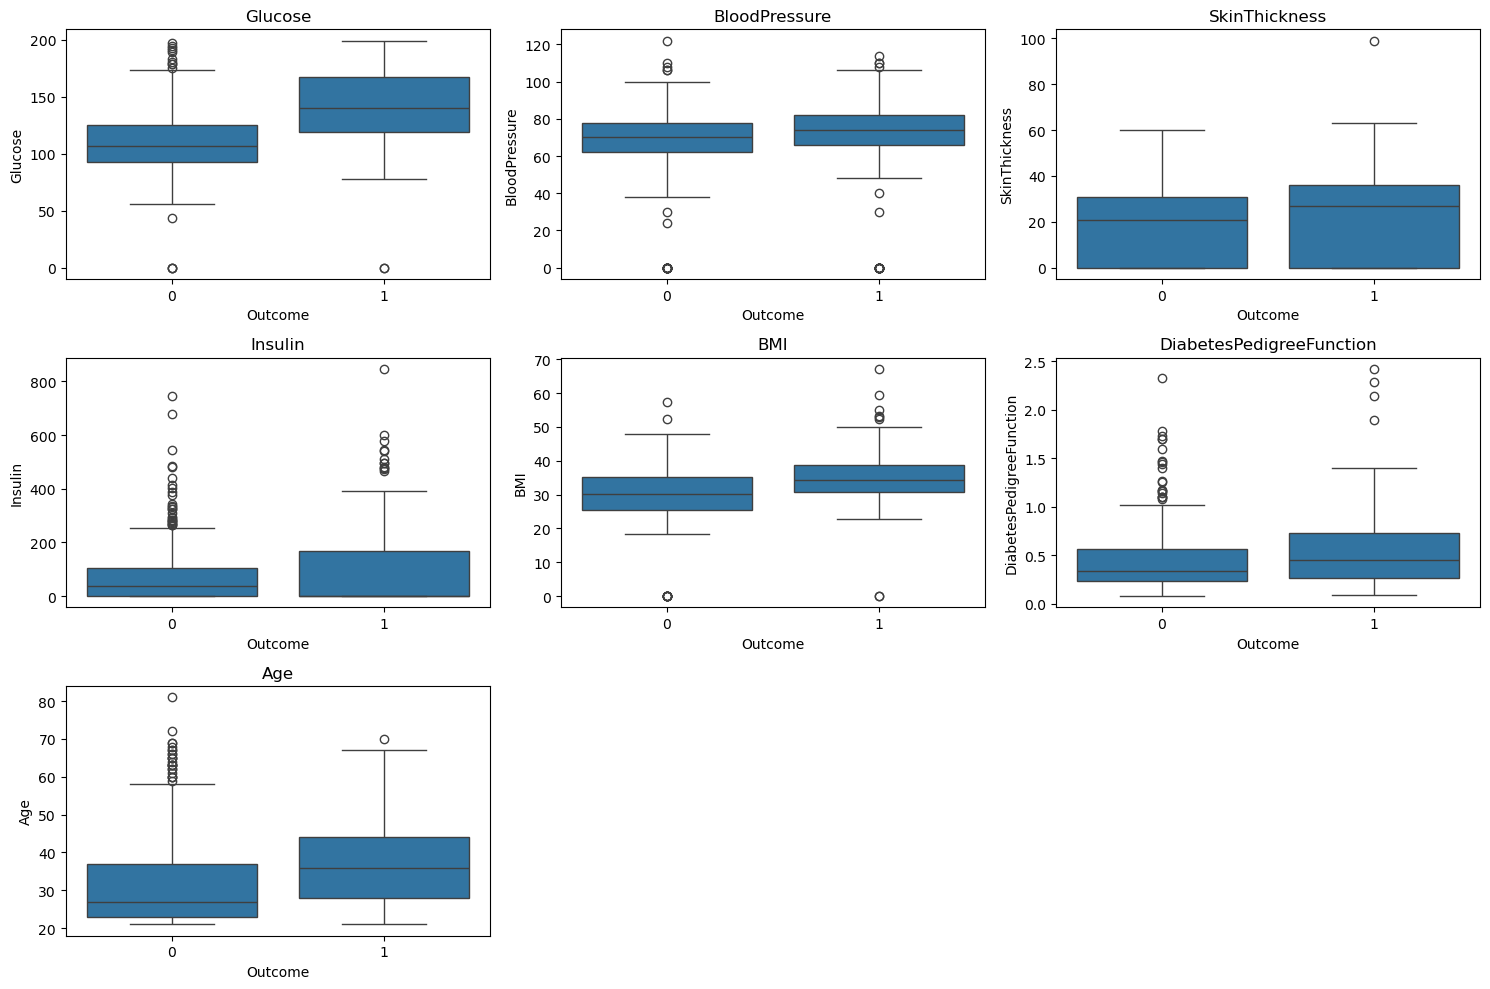

In [13]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    plt.subplot((len(cols) // 3) + 1, 3, i + 1)
    sns.boxplot(y=df[col], x='Outcome', data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

In [14]:
def impute_feature(col):
    column=col[0]
    Outcome=col[1]

    if column==0:
        if Outcome==1:
            return df[cols[i]].where(df['Outcome']==1).mean()
        else:
            return df[cols[i]].where(df['Outcome']==0).mean()
    else:
        return column

In [15]:
for i in range(0, len(cols)):
    for col in cols:
        df[col]=df[[col, 'Outcome']].apply(impute_feature, axis=1)


C:\Users\vikas\AppData\Local\Temp\ipykernel_11144\717778631.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  column=col[0]
C:\Users\vikas\AppData\Local\Temp\ipykernel_11144\717778631.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Outcome=col[1]
C:\Users\vikas\AppData\Local\Temp\ipykernel_11144\717778631.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  column=col[0]
C:\Users\vikas\AppData\Local\Temp\ipykernel_11144\7177786

In [16]:
(df[cols] == 0).sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [17]:
def bmi_category(bmi):
    if bmi<18.5:
        return "Underweight"
    elif bmi>24.9:
        return "Normal weight"
    elif bmi>29.9:
        return "Overweight"
    else:
        return "Obese"

In [18]:
df['BMI Category']=df['BMI'].apply(bmi_category)

In [19]:
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 100],
                          labels=['20-30', '30-40', '40-50', '50-60', '60+'])

In [20]:
df=pd.get_dummies(df, columns=['BMI Category', 'Age_Group'], drop_first=True, dtype=int)

In [21]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI Category_Obese,BMI Category_Underweight,Age_Group_30-40,Age_Group_40-50,Age_Group_50-60,Age_Group_60+
0,6,148.0,72.0,35.000000,142.311623,33.6,0.627,50,1,0,0,0,1,0,0
1,1,85.0,66.0,29.000000,110.639880,26.6,0.351,31,0,0,0,1,0,0,0
2,8,183.0,64.0,142.311623,142.311623,23.3,0.672,32,1,1,0,1,0,0,0
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0,0,0,0,0,0,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1,0,0,1,0,0,0


In [22]:
x=df.drop(columns='Outcome', axis=1)
y=df['Outcome']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [24]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [25]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=2)

In [26]:
from sklearn.svm import SVC

In [27]:
svc=SVC(kernel='linear')

In [28]:
svc.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
y_pred=svc.predict(x_test)

In [30]:
from sklearn.metrics import accuracy_score, precision_score

In [31]:
accuracy_score(y_test, y_pred)

0.8051948051948052

In [32]:
import pickle

In [33]:
pickle.dump(svc, open('model.pkl', 'wb'))

In [34]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))